In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fundamentals = pd.read_csv(
    "Desktop/fundamentals.csv" ,
        encoding= "cp1252"

)

print(fundamentals.head())
print(fundamentals.shape)
print(fundamentals.columns)

   Unnamed: 0 Ticker Symbol Period Ending  Accounts Payable  \
0           0           AAL    2012-12-31      3.068000e+09   
1           1           AAL    2013-12-31      4.975000e+09   
2           2           AAL    2014-12-31      4.668000e+09   
3           3           AAL    2015-12-31      5.102000e+09   
4           4           AAP    2012-12-29      2.409453e+09   

   Accounts Receivable  Add'l income/expense items  After Tax ROE  \
0         -222000000.0               -1.961000e+09           23.0   
1          -93000000.0               -2.723000e+09           67.0   
2         -160000000.0               -1.500000e+08          143.0   
3          352000000.0               -7.080000e+08          135.0   
4          -89482000.0                6.000000e+05           32.0   

   Capital Expenditures  Capital Surplus  Cash Ratio  ...  \
0         -1.888000e+09     4.695000e+09        53.0  ...   
1         -3.114000e+09     1.059200e+10        75.0  ...   
2         -5.311000e+09

In [3]:
print(fundamentals.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           1781 non-null   int64  
 1   Ticker Symbol                                        1781 non-null   object 
 2   Period Ending                                        1781 non-null   object 
 3   Accounts Payable                                     1781 non-null   float64
 4   Accounts Receivable                                  1781 non-null   float64
 5   Add'l income/expense items                           1781 non-null   float64
 6   After Tax ROE                                        1781 non-null   float64
 7   Capital Expenditures                                 1781 non-null   float64
 8   Capital Surplus                                      1781 non-null  

In [4]:
missing = fundamentals.isnull().sum()

print(
    missing[
        missing > 0
    ].sort_values(ascending=False)
)

Cash Ratio                      299
Current Ratio                   299
Quick Ratio                     299
Earnings Per Share              219
Estimated Shares Outstanding    219
For Year                        173
dtype: int64


In [5]:
missing_pct = (
    fundamentals.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_pct)

Quick Ratio                     16.788321
Cash Ratio                      16.788321
Current Ratio                   16.788321
Estimated Shares Outstanding    12.296463
Earnings Per Share              12.296463
                                  ...    
Intangible Assets                0.000000
Income Tax                       0.000000
Gross Profit                     0.000000
Gross Margin                     0.000000
Net Cash Flows-Financing         0.000000
Length: 79, dtype: float64


In [6]:
fundamentals = fundamentals.drop(
    columns=["Unnamed: 0"]
)

In [7]:
fundamentals["Period Ending"] = pd.to_datetime(
    fundamentals["Period Ending"],
    errors="coerce"
)

In [8]:
print(
    fundamentals["Period Ending"].min()
)

print(
    fundamentals["Period Ending"].max()
)

2003-06-30 00:00:00
2017-01-01 00:00:00


In [9]:
companies = [
    "AAPL",
    "MSFT",
    "WMT",
    "BA"
]

df = fundamentals[
    fundamentals["Ticker Symbol"].isin(companies)
].copy()

In [10]:
print(
    df["Ticker Symbol"].value_counts()
)

Ticker Symbol
AAPL    4
BA      4
MSFT    4
WMT     4
Name: count, dtype: int64


In [12]:
df = df.sort_values(
    [
        "Ticker Symbol",
        "Period Ending"
    ]
)

In [21]:
df["Year"] = (
    df["Period Ending"]
    .dt.year
)

In [24]:
df["Revenue Growth"] = (
    df.groupby("Ticker Symbol")
      ["Total Revenue"]
      .pct_change() * 100
)

In [25]:
print(
    df[
        [
            "Ticker Symbol",
            "Year",
            "Total Revenue",
            "Revenue Growth"
        ]
    ]
)

     Ticker Symbol  Year  Total Revenue  Revenue Growth
8             AAPL  2013   1.709100e+11             NaN
9             AAPL  2014   1.827950e+11        6.953952
10            AAPL  2015   2.337150e+11       27.856342
11            AAPL  2016   2.156390e+11       -7.734206
186             BA  2013   8.662300e+10             NaN
187             BA  2014   9.076200e+10        4.778177
188             BA  2015   9.611400e+10        5.896741
189             BA  2016   9.457100e+10       -1.605385
1107          MSFT  2013   7.784900e+10             NaN
1108          MSFT  2014   8.683300e+10       11.540290
1109          MSFT  2015   9.358000e+10        7.770087
1110          MSFT  2016   8.532000e+10       -8.826672
1706           WMT  2013   4.686510e+11             NaN
1707           WMT  2014   4.762940e+11        1.630851
1708           WMT  2015   4.856510e+11        1.964543
1709           WMT  2016   4.821300e+11       -0.725006


In [26]:
df["Gross Margin Calc"] = (
    df["Gross Profit"]
    / df["Total Revenue"]
    * 100
)

In [31]:
df["Operating Margin Calc"] = (
    df["Operating Income"]
    / df["Total Revenue"]
    * 100
)

In [33]:
df["Net Margin Calc"] = (
    df["Net Income"]
    / df["Total Revenue"]
    * 100
)

In [35]:
df["ROA"] = (
    df["Net Income"]
    / df["Total Assets"]
    * 100
)

In [37]:
df["ROE"] = (
    df["Net Income"]
    / df["Total Equity"]
    * 100
)

In [39]:
df["Current Ratio Calc"] = (
    df["Total Current Assets"]
    / df["Total Current Liabilities"]
)

In [41]:
df["Quick Ratio Calc"] = (
    df["Cash and Cash Equivalents"]
    + df["Short-Term Investments"]
    + df["Net Receivables"]
) / df["Total Current Liabilities"]

In [43]:
df[
    [
        "Ticker Symbol",
        "Year",
        "Quick Ratio",
        "Quick Ratio Calc"
    ]
]

,Ticker Symbol,Year,Quick Ratio,Quick Ratio Calc
8,AAPL,2013,164.0,1.480599
9,AAPL,2014,105.0,0.892290
10,AAPL,2015,108.0,0.892495
11,AAPL,2016,133.0,1.220844
186,BA,2013,43.0,0.430447
187,BA,2014,44.0,0.435615
188,BA,2015,42.0,0.416111
189,BA,2016,38.0,0.384749
1107,MSFT,2013,266.0,2.569420
1108,MSFT,2014,245.0,2.349458


In [48]:
df["Cash Ratio Calc"] = (
    df["Cash and Cash Equivalents"]
    + df["Short-Term Investments"]
) / df["Total Current Liabilities"]

In [50]:
df["Debt Ratio"] = (
    df["Total Liabilities"]
    / df["Total Assets"]
)

In [52]:
df["LT Debt to Equity"] = (
    df["Long-Term Debt"]
    / df["Total Equity"]
)

In [54]:
df["Interest Coverage"] = (
    df["Earnings Before Interest and Tax"]
    / df["Interest Expense"]
)

In [56]:
df["Interest Coverage"] = (
    df["Earnings Before Interest and Tax"]
    / df["Interest Expense"]
)

In [60]:
df["Financing Cash Flow"] = (
    df["Net Cash Flows-Financing"]
)

In [72]:
[c for c in df.columns if "Cash Flow" in c or "Cash" in c]

['Cash Ratio',
 'Cash and Cash Equivalents',
 'Net Cash Flow',
 'Net Cash Flow-Operating',
 'Net Cash Flows-Financing',
 'Net Cash Flows-Investing',
 'Cash Ratio Calc',
 'Financing Cash Flow',
 'Free Cash Flow']

In [74]:
df["Operating Cash Flow"] = df["Net Cash Flow-Operating"]

In [76]:
df["OCF Conversion"] = np.where(
    df["Net Income"] != 0,
    df["Operating Cash Flow"]
    / df["Net Income"],
    np.nan
)

In [78]:
print(
    df[
        [
            "Ticker Symbol",
            "Year",
            "Net Income",
            "Operating Cash Flow",
            "OCF Conversion"
        ]
    ]
)

     Ticker Symbol  Year    Net Income  Operating Cash Flow  OCF Conversion
8             AAPL  2013  3.703700e+10         5.366600e+10        1.448983
9             AAPL  2014  3.951000e+10         5.971300e+10        1.511339
10            AAPL  2015  5.339400e+10         8.126600e+10        1.522006
11            AAPL  2016  4.568700e+10         6.582400e+10        1.440760
186             BA  2013  4.585000e+09         8.179000e+09        1.783860
187             BA  2014  5.446000e+09         8.858000e+09        1.626515
188             BA  2015  5.176000e+09         9.363000e+09        1.808926
189             BA  2016  4.895000e+09         1.049900e+10        2.144842
1107          MSFT  2013  2.186300e+10         2.883300e+10        1.318803
1108          MSFT  2014  2.207400e+10         3.250200e+10        1.472411
1109          MSFT  2015  1.219300e+10         2.966800e+10        2.433199
1110          MSFT  2016  1.679800e+10         3.332500e+10        1.983867
1706        

In [64]:
print(
    df[
        [
            "Capital Expenditures",
            "Net Cash Flow-Operating"
        ]
    ].head(20)
)

      Capital Expenditures  Net Cash Flow-Operating
8            -8.165000e+09             5.366600e+10
9            -9.571000e+09             5.971300e+10
10           -1.124700e+10             8.126600e+10
11           -1.273400e+10             6.582400e+10
186          -2.098000e+09             8.179000e+09
187          -2.236000e+09             8.858000e+09
188          -2.450000e+09             9.363000e+09
189          -2.613000e+09             1.049900e+10
1107         -4.257000e+09             2.883300e+10
1108         -5.485000e+09             3.250200e+10
1109         -5.944000e+09             2.966800e+10
1110         -8.343000e+09             3.332500e+10
1706         -1.289800e+10             2.559100e+10
1707         -1.311500e+10             2.325700e+10
1708         -1.217400e+10             2.856400e+10
1709         -1.147700e+10             2.738900e+10


In [68]:
df["Free Cash Flow"] = (
    df["Net Cash Flow-Operating"]
    + df["Capital Expenditures"]
)

In [82]:
# Leverage / Solvency Ratios

df["Debt to Equity"] = np.where(
    df["Total Equity"] != 0,
    df["Total Liabilities"] / df["Total Equity"],
    np.nan
)

df["Debt Ratio"] = np.where(
    df["Total Assets"] != 0,
    df["Total Liabilities"] / df["Total Assets"],
    np.nan
)

df["LT Debt to Equity"] = np.where(
    df["Total Equity"] != 0,
    df["Long-Term Debt"] / df["Total Equity"],
    np.nan
)

df["Interest Coverage"] = np.where(
    df["Interest Expense"] != 0,
    df["Earnings Before Interest and Tax"] / df["Interest Expense"],
    np.nan
)

In [84]:
print([
    "Debt to Equity",
    "Debt Ratio",
    "LT Debt to Equity",
    "Interest Coverage"
])

print(df[
    [
        "Ticker Symbol",
        "Year",
        "Debt to Equity",
        "Debt Ratio",
        "LT Debt to Equity",
        "Interest Coverage"
    ]
].head())

['Debt to Equity', 'Debt Ratio', 'LT Debt to Equity', 'Interest Coverage']
    Ticker Symbol  Year  Debt to Equity  Debt Ratio  LT Debt to Equity  \
8            AAPL  2013        0.675449    0.403145           0.137273   
9            AAPL  2014        1.078397    0.518860           0.259864   
10           AAPL  2015        1.432617    0.588920           0.446810   
11           AAPL  2016        1.508292    0.601322           0.588129   
186            BA  2013        5.229445    0.839472           0.542655   

     Interest Coverage  
8                  NaN  
9                  NaN  
10                 NaN  
11                 NaN  
186          17.145078  


In [86]:
financial_summary = df[
    [
        "Ticker Symbol",
        "Year",
        "Total Revenue",
        "Revenue Growth",
        "Gross Margin Calc",
        "Operating Margin Calc",
        "Net Margin Calc",
        "ROA",
        "ROE",
        "Current Ratio Calc",
        "Quick Ratio Calc",
        "Cash Ratio Calc",
        "Debt to Equity",
        "Debt Ratio",
        "Interest Coverage",
        "Operating Cash Flow",
        "Free Cash Flow",
        "OCF Conversion"
    ]
].copy()

In [88]:
average_growth = (
    np.mean(
        df["Revenue Growth"].dropna()
    )
)

print(
    "Average revenue growth:",
    average_growth
)

Average revenue growth: 4.124976058084777


In [90]:
growth_volatility = np.std(
    df["Revenue Growth"].dropna()
)

print(
    "Revenue growth volatility:",
    growth_volatility
)

Revenue growth volatility: 9.21345601121326


In [92]:
company_stats = (
    df.groupby("Ticker Symbol")
      .agg(
          Average_Revenue_Growth=(
              "Revenue Growth",
              "mean"
          ),
          Average_Net_Margin=(
              "Net Margin Calc",
              "mean"
          ),
          Average_ROE=(
              "ROE",
              "mean"
          ),
          Average_Current_Ratio=(
              "Current Ratio Calc",
              "mean"
          ),
          Average_Debt_Equity=(
              "Debt to Equity",
              "mean"
          )
      )
)

print(company_stats)

               Average_Revenue_Growth  Average_Net_Margin  Average_ROE  \
Ticker Symbol                                                            
AAPL                         9.025363           21.829355    36.439187   
BA                           3.023177            5.463659   193.630525   
MSFT                         3.494568           21.555698    22.709242   
WMT                          0.956796            3.352031    20.406033   

               Average_Current_Ratio  Average_Debt_Equity  
Ticker Symbol                                              
AAPL                        1.305048             1.173689  
BA                          1.317214            34.502803  
MSFT                        2.510517             1.148284  
WMT                         0.904722             1.580856  


In [100]:
import os

print(os.getcwd())

C:\Users\Lenovo


In [102]:
import os

output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

In [104]:
plt.savefig(
    os.path.join(output_folder, "revenue_comparison.png"),
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [108]:
import os

output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

print("Charts will be saved to:", os.path.abspath(output_folder))

Charts will be saved to: C:\Users\Lenovo\output


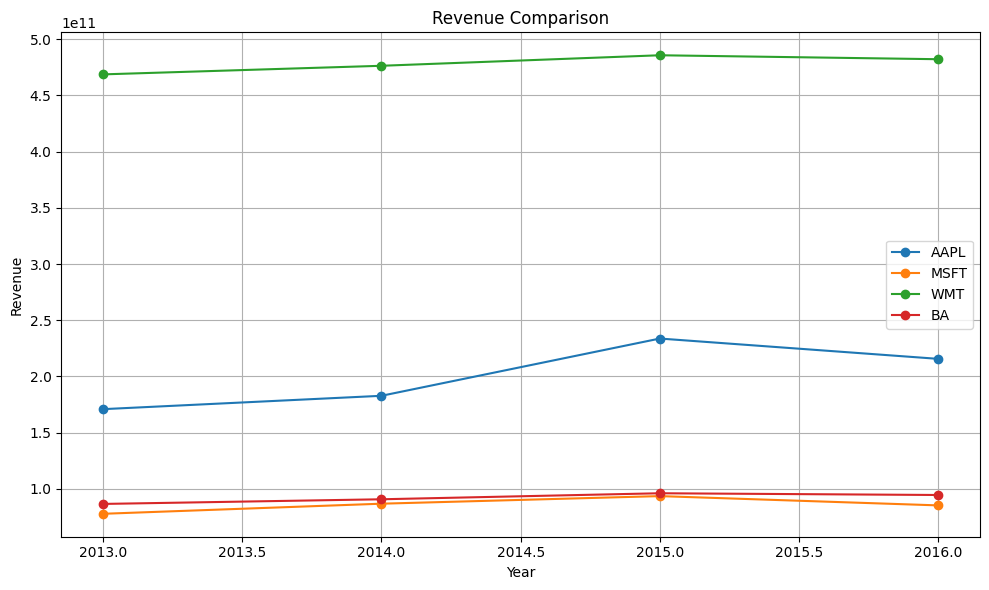

In [126]:
plt.figure(figsize=(10, 6))

for company in companies:
    company_data = df[df["Ticker Symbol"] == company]

    plt.plot(
        company_data["Year"],
        company_data["Total Revenue"],
        marker="o",
        label=company
    )

plt.title("Revenue Comparison")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "revenue_comparison.png"),
    dpi=300
)

plt.show()

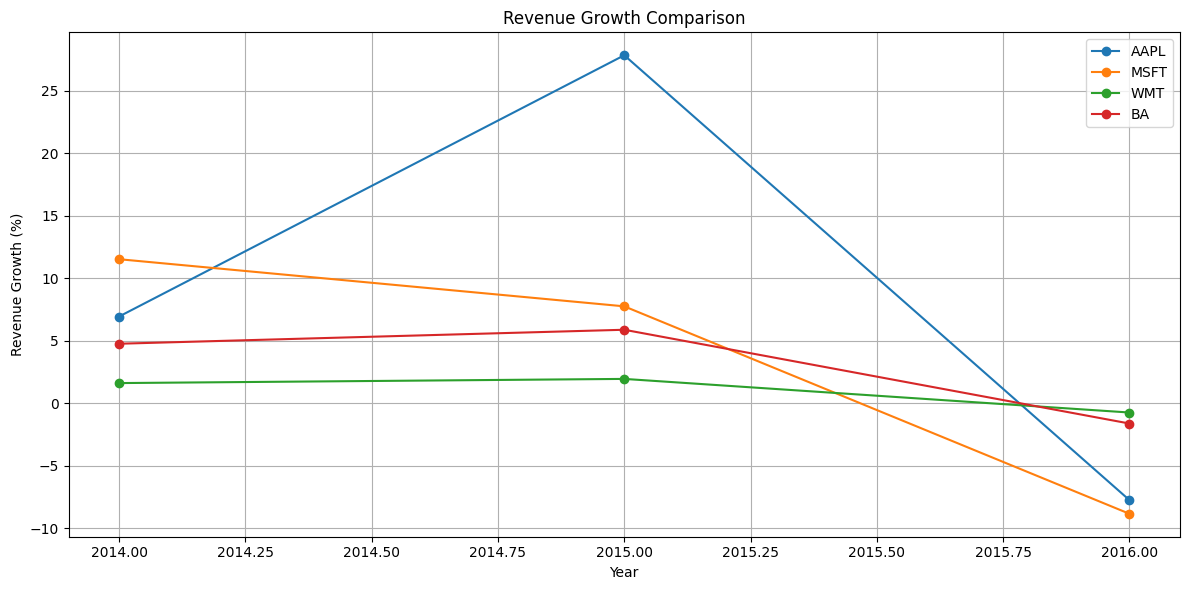

In [128]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = df[
        df["Ticker Symbol"] == company
    ]

    plt.plot(
        company_data["Year"],
        company_data["Revenue Growth"],
        marker="o",
        label=company
    )

plt.title("Revenue Growth Comparison")

plt.xlabel("Year")
plt.ylabel("Revenue Growth (%)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
     os.path.join(output_folder, "revenue_growth.png"),
    dpi=300
)

plt.show()

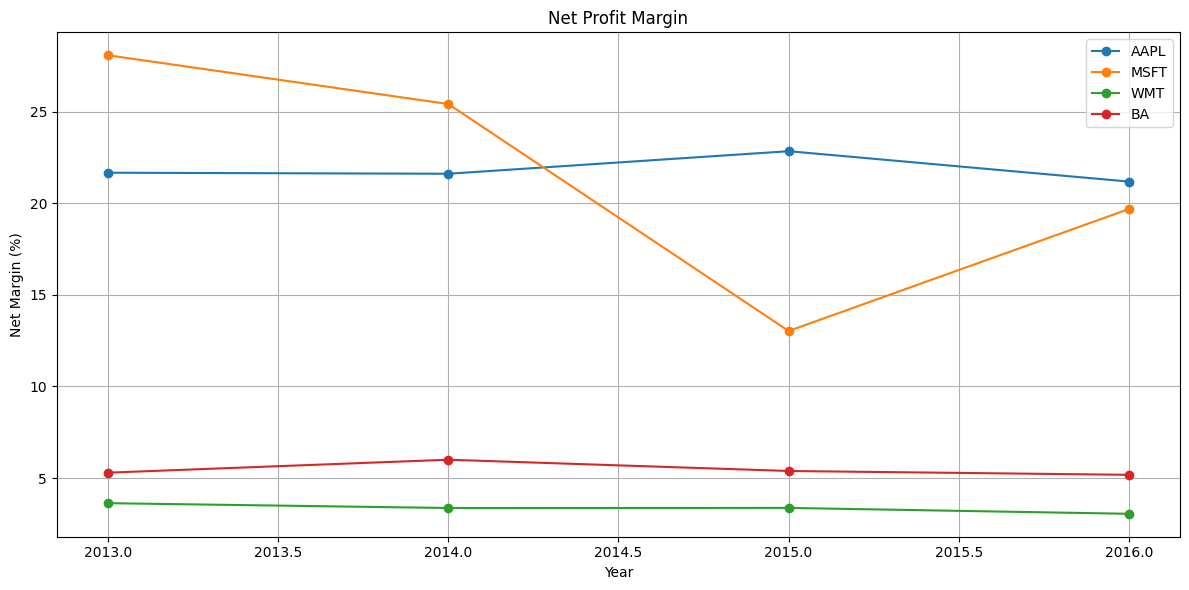

In [132]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = df[
        df["Ticker Symbol"] == company
    ]

    plt.plot(
        company_data["Year"],
        company_data["Net Margin Calc"],
        marker="o",
        label=company
    )

plt.title("Net Profit Margin")

plt.xlabel("Year")
plt.ylabel("Net Margin (%)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(os.path.join(output_folder, "net_margin.png"),
    dpi=300
)

plt.show()

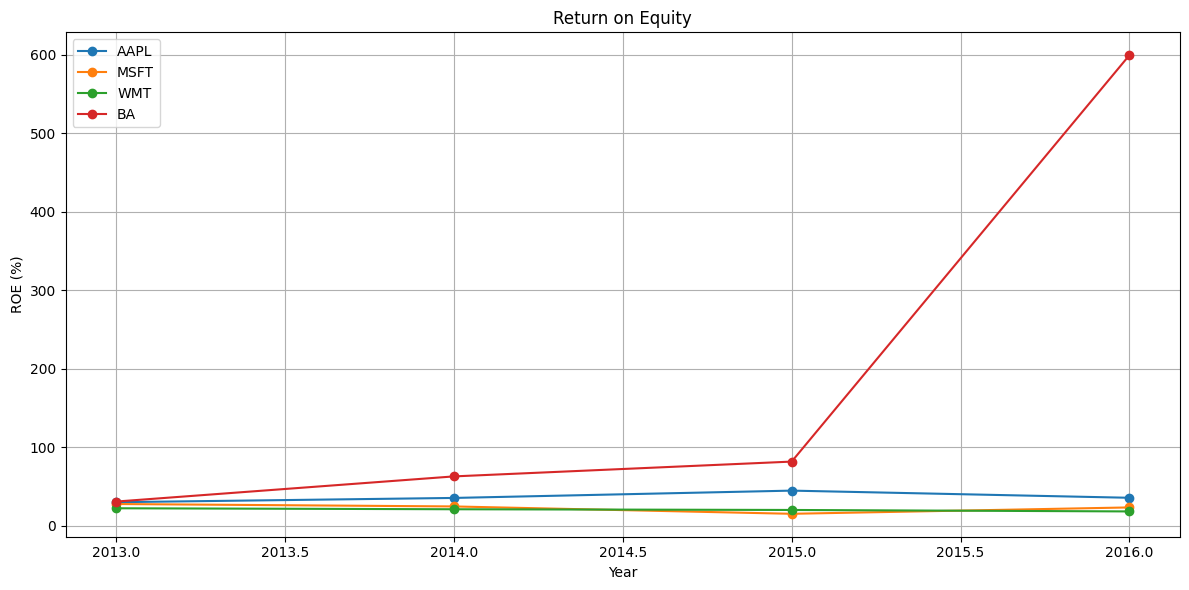

In [136]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = df[
        df["Ticker Symbol"] == company
    ]

    plt.plot(
        company_data["Year"],
        company_data["ROE"],
        marker="o",
        label=company
    )

plt.title("Return on Equity")

plt.xlabel("Year")
plt.ylabel("ROE (%)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(os.path.join(output_folder,"roe.png"),
    dpi=300
)

plt.show()

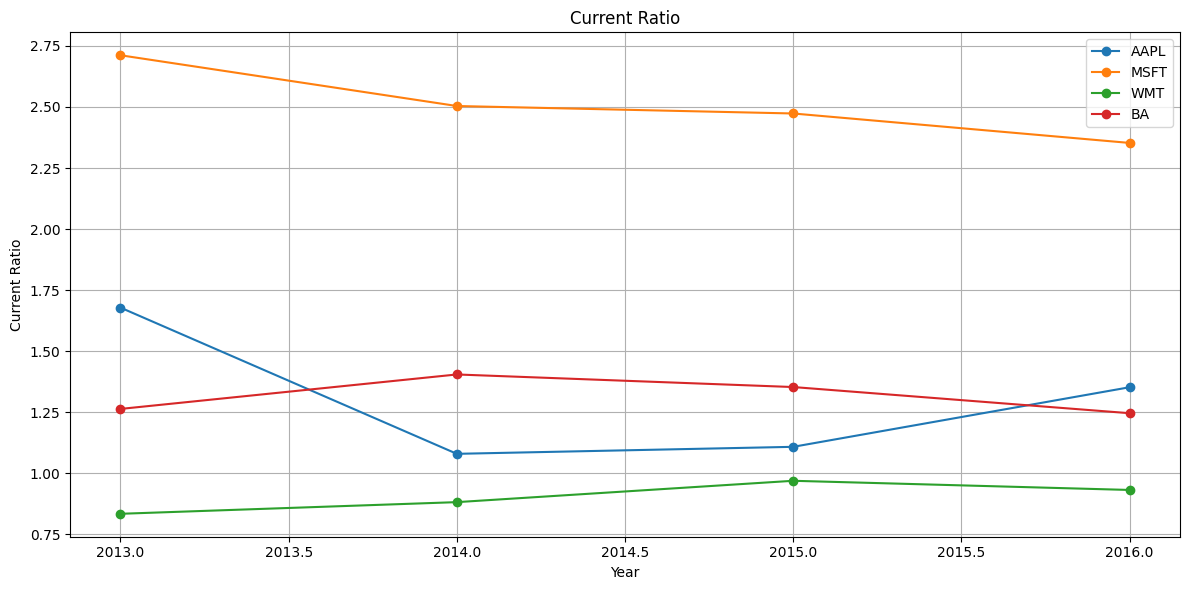

In [138]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = df[
        df["Ticker Symbol"] == company
    ]

    plt.plot(
        company_data["Year"],
        company_data["Current Ratio Calc"],
        marker="o",
        label=company
    )

plt.title("Current Ratio")

plt.xlabel("Year")
plt.ylabel("Current Ratio")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder,"current_ratio.png"),
    dpi=300
)

plt.show()

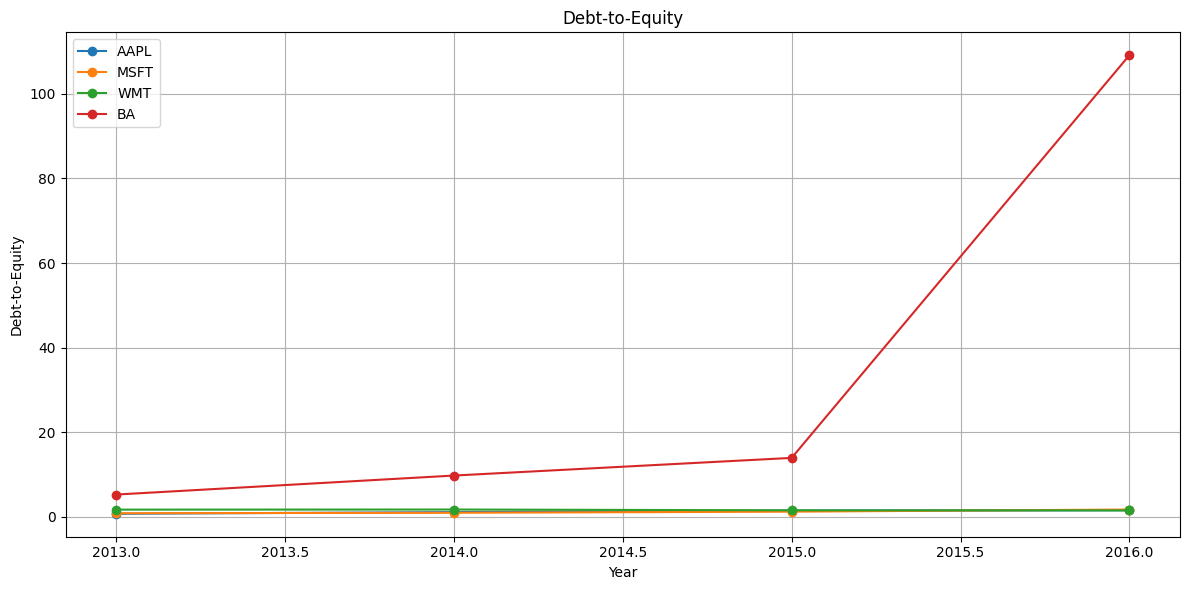

In [142]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = df[
        df["Ticker Symbol"] == company
    ]

    plt.plot(
        company_data["Year"],
        company_data["Debt to Equity"],
        marker="o",
        label=company
    )

plt.title("Debt-to-Equity")

plt.xlabel("Year")
plt.ylabel("Debt-to-Equity")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder,"debt_to_equity.png"),
    dpi=300
)

plt.show()

In [144]:
prices = pd.read_csv(
    "Desktop/prices-split-adjusted.csv",
            encoding= "cp1252"

)

print(prices.head())
print(prices.shape)

         date symbol        open       close         low        high  \
0  2016-01-05   WLTW  123.430000  125.839996  122.309998  126.250000   
1  2016-01-06   WLTW  125.239998  119.980003  119.940002  125.540001   
2  2016-01-07   WLTW  116.379997  114.949997  114.930000  119.739998   
3  2016-01-08   WLTW  115.480003  116.620003  113.500000  117.440002   
4  2016-01-11   WLTW  117.010002  114.970001  114.089996  117.330002   

      volume  
0  2163600.0  
1  2386400.0  
2  2489500.0  
3  2006300.0  
4  1408600.0  
(851264, 7)


In [146]:
prices["date"] = pd.to_datetime(
    prices["date"]
)

In [148]:
stock_prices = prices[
    prices["symbol"].isin(companies)
].copy()

In [150]:
stock_prices = stock_prices.sort_values(
    [
        "symbol",
        "date"
    ]
)

In [152]:
stock_prices["Daily Return"] = (
    stock_prices
    .groupby("symbol")["close"]
    .pct_change()
)

In [154]:
stock_prices["Growth of $1"] = (
    1 + stock_prices["Daily Return"]
).groupby(
    stock_prices["symbol"]
).cumprod()

In [156]:
stock_prices["Investment Value"] = (
    stock_prices["Growth of $1"] * 100
)

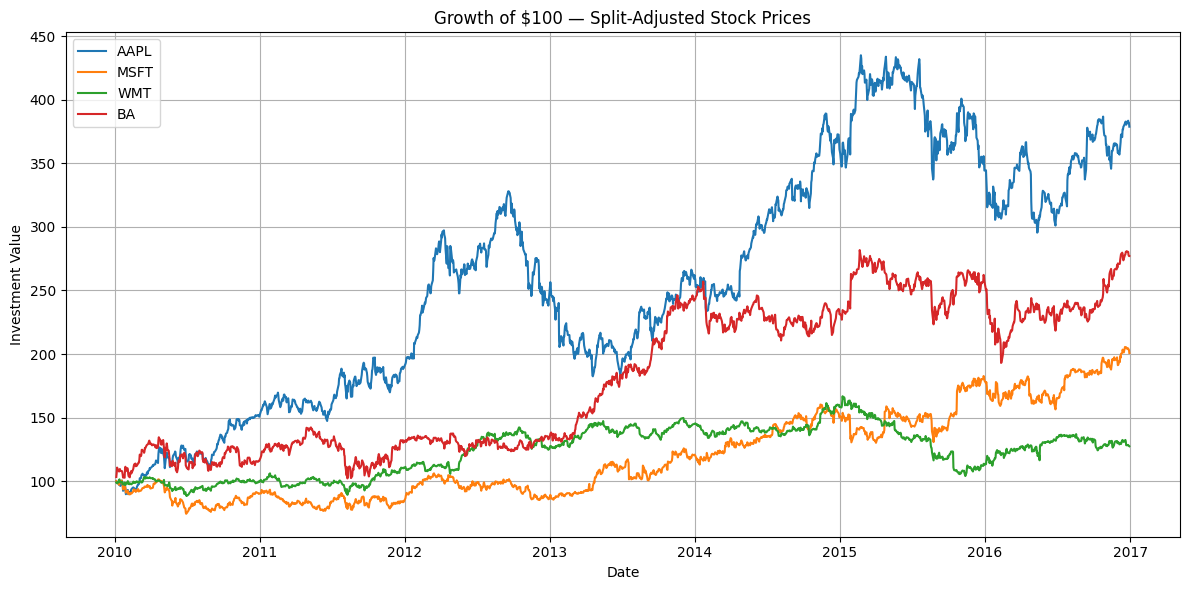

In [160]:
plt.figure(figsize=(12, 6))

for company in companies:

    company_data = stock_prices[
        stock_prices["symbol"] == company
    ]

    plt.plot(
        company_data["date"],
        company_data["Investment Value"],
        label=company
    )

plt.title(
    "Growth of $100 — Split-Adjusted Stock Prices"
)

plt.xlabel("Date")
plt.ylabel("Investment Value")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder,"stock_growth.png"),
    dpi=300
)

plt.show()

In [162]:
volatility = (
    stock_prices
    .groupby("symbol")["Daily Return"]
    .std()
    * np.sqrt(252)
)

In [164]:
print(volatility)

symbol
AAPL    0.262210
BA      0.240741
MSFT    0.231882
WMT     0.163669
Name: Daily Return, dtype: float64


In [166]:
stock_prices["Running Peak"] = (
    stock_prices
    .groupby("symbol")["Investment Value"]
    .cummax()
)

In [168]:
stock_prices["Running Peak"] = (
    stock_prices
    .groupby("symbol")["Investment Value"]
    .cummax()
)

In [170]:
stock_prices["Drawdown"] = (
    stock_prices["Investment Value"]
    / stock_prices["Running Peak"]
    - 1
)

In [172]:
matched_stock = stock_prices[
    (
        stock_prices["date"].dt.year >= 2013
    )
    &
    (
        stock_prices["date"].dt.year <= 2016
    )
].copy()

In [175]:
matched_stock["Year"] = (
    matched_stock["date"].dt.year
)

In [177]:
annual_returns = (
    matched_stock
    .groupby(
        ["symbol", "Year"]
    )["Daily Return"]
    .apply(
        lambda x: (1 + x).prod() - 1
    )
    * 100
)

annual_returns = (
    annual_returns
    .reset_index()
)

In [179]:
financial_for_correlation = df[
    [
        "Ticker Symbol",
        "Year",
        "Revenue Growth",
        "Net Margin Calc",
        "ROE",
        "Free Cash Flow"
    ]
]

In [181]:
combined = financial_for_correlation.merge(
    annual_returns,
    left_on=[
        "Ticker Symbol",
        "Year"
    ],
    right_on=[
        "symbol",
        "Year"
    ],
    how="inner"
)

In [183]:
combined = combined.rename(
    columns={
        "Daily Return": "Annual Stock Return"
    }
)

In [185]:
print(combined.columns)

Index(['Ticker Symbol', 'Year', 'Revenue Growth', 'Net Margin Calc', 'ROE',
       'Free Cash Flow', 'symbol', 'Annual Stock Return'],
      dtype='object')


In [187]:
correlation = combined[
    [
        "Revenue Growth",
        "Net Margin Calc",
        "ROE",
        "Free Cash Flow",
        "Annual Stock Return"
    ]
].corr()

In [189]:
print(correlation)

                     Revenue Growth  Net Margin Calc       ROE  \
Revenue Growth             1.000000         0.301276 -0.158675   
Net Margin Calc            0.301276         1.000000 -0.230042   
ROE                       -0.158675        -0.230042  1.000000   
Free Cash Flow             0.440110         0.745607 -0.238725   
Annual Stock Return       -0.044574         0.165909 -0.100151   

                     Free Cash Flow  Annual Stock Return  
Revenue Growth             0.440110            -0.044574  
Net Margin Calc            0.745607             0.165909  
ROE                       -0.238725            -0.100151  
Free Cash Flow             1.000000            -0.123494  
Annual Stock Return       -0.123494             1.000000  


In [195]:
# Calculate maximum drawdown
max_drawdown = (
    stock_prices.groupby("symbol")["Drawdown"]
    .min()
)

print(max_drawdown)

symbol
AAPL   -0.443769
BA     -0.315015
MSFT   -0.266964
WMT    -0.376368
Name: Drawdown, dtype: float64


In [197]:
import os
import pandas as pd

# Create Excel output folder if it doesn't exist
excel_folder = "excel"
os.makedirs(excel_folder, exist_ok=True)

# Excel file path
output_file = os.path.join(
    excel_folder,
    "Financial_Analysis.xlsx"
)

# Create Excel workbook
with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Financial Ratios",
        index=False
    )

    company_stats.to_excel(
        writer,
        sheet_name="Company Summary"
    )

    annual_returns.to_excel(
        writer,
        sheet_name="Stock Returns",
        index=False
    )

    volatility.to_frame(
        "Annualized Volatility"
    ).to_excel(
        writer,
        sheet_name="Risk"
    )

    max_drawdown.to_frame(
        "Maximum Drawdown"
    ).to_excel(
        writer,
        sheet_name="Drawdown"
    )

    correlation.to_excel(
        writer,
        sheet_name="Correlation"
    )

print("Excel file created successfully!")
print("Saved at:", os.path.abspath(output_file))

Excel file created successfully!
Saved at: C:\Users\Lenovo\excel\Financial_Analysis.xlsx


In [199]:
check = df[
    [
        "Ticker Symbol",
        "Year",
        "Gross Margin",
        "Gross Margin Calc",
        "Operating Margin",
        "Operating Margin Calc",
        "Profit Margin",
        "Net Margin Calc"
    ]
]

print(check)

     Ticker Symbol  Year  Gross Margin  Gross Margin Calc  Operating Margin  \
8             AAPL  2013          38.0          37.624481              29.0   
9             AAPL  2014          39.0          38.588036              29.0   
10            AAPL  2015          40.0          40.059902              30.0   
11            AAPL  2016          39.0          39.075956              28.0   
186             BA  2013          15.0          15.417383               8.0   
187             BA  2014          15.0          15.435975               8.0   
188             BA  2015          15.0          14.593087               8.0   
189             BA  2016          15.0          14.572120               6.0   
1107          MSFT  2013          74.0          73.814693              34.0   
1108          MSFT  2014          69.0          68.816003              32.0   
1109          MSFT  2015          65.0          64.695448              19.0   
1110          MSFT  2016          62.0          61.5

In [201]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["Ticker Symbol"].unique())
print(df["Year"].unique())

(16, 96)
Ticker Symbol                 0
Period Ending                 0
Accounts Payable              0
Accounts Receivable           0
Add'l income/expense items    0
                             ..
Financing Cash Flow           0
Free Cash Flow                0
Operating Cash Flow           0
OCF Conversion                0
Debt to Equity                0
Length: 96, dtype: int64
0
['AAPL' 'BA' 'MSFT' 'WMT']
[2013 2014 2015 2016]


In [203]:
print(
    df[
        [
            "Total Revenue",
            "Net Income",
            "Total Assets",
            "Total Equity"
        ]
    ].describe()
)

       Total Revenue    Net Income  Total Assets  Total Equity
count   1.600000e+01  1.600000e+01  1.600000e+01  1.600000e+01
mean    2.142148e+11  2.079600e+10  1.821729e+11  7.179612e+10
std     1.649031e+11  1.522779e+10  6.831197e+10  4.235455e+10
min     7.784900e+10  4.585000e+09  8.999700e+10  8.170000e+08
25%     8.977975e+10  1.050625e+10  1.304252e+11  5.771650e+10
50%     1.335120e+11  1.658050e+10  1.966375e+11  7.951350e+10
75%     2.924490e+11  2.581475e+10  2.053132e+11  9.522475e+10
max     4.856510e+11  5.339400e+10  3.216860e+11  1.282490e+11


In [205]:
# Create dashboard summary

dashboard = (
    df.groupby("Ticker Symbol")
      .agg(
          Average_Revenue=("Total Revenue", "mean"),
          Average_Revenue_Growth=("Revenue Growth", "mean"),
          Average_Net_Margin=("Net Margin Calc", "mean"),
          Average_ROE=("ROE", "mean"),
          Average_Current_Ratio=("Current Ratio Calc", "mean"),
          Average_Debt_to_Equity=("Debt to Equity", "mean"),
          Average_OCF_Conversion=("OCF Conversion", "mean")
      )
      .reset_index()
)

dashboard

,Ticker Symbol,Average_Revenue,Average_Revenue_Growth,Average_Net_Margin,Average_ROE,Average_Current_Ratio,Average_Debt_to_Equity,Average_OCF_Conversion
0,AAPL,2.007648e+11,9.025363,21.829355,36.439187,1.305048,1.173689,1.480772
1,BA,9.201750e+10,3.023177,5.463659,193.630525,1.317214,34.502803,1.841036
2,MSFT,8.589550e+10,3.494568,21.555698,22.709242,2.510517,1.148284,1.802070
3,WMT,4.781815e+11,0.956796,3.352031,20.406033,0.904722,1.580856,1.641653


In [207]:
dashboard = dashboard.round(2)

dashboard

,Ticker Symbol,Average_Revenue,Average_Revenue_Growth,Average_Net_Margin,Average_ROE,Average_Current_Ratio,Average_Debt_to_Equity,Average_OCF_Conversion
0,AAPL,2.007648e+11,9.03,21.83,36.44,1.31,1.17,1.48
1,BA,9.201750e+10,3.02,5.46,193.63,1.32,34.50,1.84
2,MSFT,8.589550e+10,3.49,21.56,22.71,2.51,1.15,1.80
3,WMT,4.781815e+11,0.96,3.35,20.41,0.90,1.58,1.64


In [209]:
import os
from openpyxl import load_workbook

excel_file = os.path.join(
    "excel",
    "Financial_Analysis.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    dashboard.to_excel(
        writer,
        sheet_name="Dashboard",
        index=False
    )

print("Dashboard sheet added successfully!")

Dashboard sheet added successfully!


In [211]:
stock_summary = (
    annual_returns
    .groupby("symbol")["Daily Return"]
    .agg(
        Average_Annual_Return="mean",
        Best_Annual_Return="max",
        Worst_Annual_Return="min"
    )
    .reset_index()
)

stock_summary = stock_summary.round(2)

stock_summary

,symbol,Average_Annual_Return,Best_Annual_Return,Worst_Annual_Return
0,AAPL,12.13,37.72,-4.64
1,BA,23.81,81.12,-4.77
2,MSFT,23.92,40.06,12.00
3,WMT,2.15,15.33,-28.62


In [213]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    stock_summary.to_excel(
        writer,
        sheet_name="Stock Performance",
        index=False
    )

print("Stock Performance sheet added successfully!")

Stock Performance sheet added successfully!


In [215]:
# Company-level financial insights

insights = dashboard.copy()

print("FINANCIAL PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in insights.iterrows():
    print(f"\n{row['Ticker Symbol']}")
    print("-" * 30)
    print(f"Average Revenue Growth: {row['Average_Revenue_Growth']:.2f}%")
    print(f"Average Net Margin:      {row['Average_Net_Margin']:.2f}%")
    print(f"Average ROE:              {row['Average_ROE']:.2f}%")
    print(f"Average Current Ratio:    {row['Average_Current_Ratio']:.2f}")
    print(f"Average Debt/Equity:      {row['Average_Debt_to_Equity']:.2f}")
    print(f"Average OCF Conversion:   {row['Average_OCF_Conversion']:.2f}")

FINANCIAL PERFORMANCE SUMMARY

AAPL
------------------------------
Average Revenue Growth: 9.03%
Average Net Margin:      21.83%
Average ROE:              36.44%
Average Current Ratio:    1.31
Average Debt/Equity:      1.17
Average OCF Conversion:   1.48

BA
------------------------------
Average Revenue Growth: 3.02%
Average Net Margin:      5.46%
Average ROE:              193.63%
Average Current Ratio:    1.32
Average Debt/Equity:      34.50
Average OCF Conversion:   1.84

MSFT
------------------------------
Average Revenue Growth: 3.49%
Average Net Margin:      21.56%
Average ROE:              22.71%
Average Current Ratio:    2.51
Average Debt/Equity:      1.15
Average OCF Conversion:   1.80

WMT
------------------------------
Average Revenue Growth: 0.96%
Average Net Margin:      3.35%
Average ROE:              20.41%
Average Current Ratio:    0.90
Average Debt/Equity:      1.58
Average OCF Conversion:   1.64


In [217]:
final_summary = dashboard.merge(
    stock_summary,
    left_on="Ticker Symbol",
    right_on="symbol",
    how="left"
)

final_summary = final_summary.drop(
    columns=["symbol"]
)

final_summary = final_summary.round(2)

final_summary

,Ticker Symbol,Average_Revenue,Average_Revenue_Growth,Average_Net_Margin,Average_ROE,Average_Current_Ratio,Average_Debt_to_Equity,Average_OCF_Conversion,Average_Annual_Return,Best_Annual_Return,Worst_Annual_Return
0,AAPL,2.007648e+11,9.03,21.83,36.44,1.31,1.17,1.48,12.13,37.72,-4.64
1,BA,9.201750e+10,3.02,5.46,193.63,1.32,34.50,1.84,23.81,81.12,-4.77
2,MSFT,8.589550e+10,3.49,21.56,22.71,2.51,1.15,1.80,23.92,40.06,12.00
3,WMT,4.781815e+11,0.96,3.35,20.41,0.90,1.58,1.64,2.15,15.33,-28.62


In [219]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    final_summary.to_excel(
        writer,
        sheet_name="Final Summary",
        index=False
    )

print("Final Summary added successfully!")

Final Summary added successfully!


In [221]:
print("Highest Average Revenue Growth:")
print(
    final_summary.loc[
        final_summary["Average_Revenue_Growth"].idxmax()
    ]
    [["Ticker Symbol", "Average_Revenue_Growth"]]
)

print("\nHighest Average Net Margin:")
print(
    final_summary.loc[
        final_summary["Average_Net_Margin"].idxmax()
    ]
    [["Ticker Symbol", "Average_Net_Margin"]]
)

print("\nHighest Average ROE:")
print(
    final_summary.loc[
        final_summary["Average_ROE"].idxmax()
    ]
    [["Ticker Symbol", "Average_ROE"]]
)

print("\nHighest Average Current Ratio:")
print(
    final_summary.loc[
        final_summary["Average_Current_Ratio"].idxmax()
    ]
    [["Ticker Symbol", "Average_Current_Ratio"]]
)

print("\nHighest Average Debt-to-Equity:")
print(
    final_summary.loc[
        final_summary["Average_Debt_to_Equity"].idxmax()
    ]
    [["Ticker Symbol", "Average_Debt_to_Equity"]]
)

print("\nHighest Average Annual Stock Return:")
print(
    final_summary.loc[
        final_summary["Average_Annual_Return"].idxmax()
    ]
    [["Ticker Symbol", "Average_Annual_Return"]]
)

Highest Average Revenue Growth:
Ticker Symbol             AAPL
Average_Revenue_Growth    9.03
Name: 0, dtype: object

Highest Average Net Margin:
Ticker Symbol          AAPL
Average_Net_Margin    21.83
Name: 0, dtype: object

Highest Average ROE:
Ticker Symbol        BA
Average_ROE      193.63
Name: 1, dtype: object

Highest Average Current Ratio:
Ticker Symbol            MSFT
Average_Current_Ratio    2.51
Name: 2, dtype: object

Highest Average Debt-to-Equity:
Ticker Symbol               BA
Average_Debt_to_Equity    34.5
Name: 1, dtype: object

Highest Average Annual Stock Return:
Ticker Symbol             MSFT
Average_Annual_Return    23.92
Name: 2, dtype: object


In [223]:
correlation.round(2)

,Revenue Growth,Net Margin Calc,ROE,Free Cash Flow,Annual Stock Return
Revenue Growth,1.00,0.30,-0.16,0.44,-0.04
Net Margin Calc,0.30,1.00,-0.23,0.75,0.17
ROE,-0.16,-0.23,1.00,-0.24,-0.10
Free Cash Flow,0.44,0.75,-0.24,1.00,-0.12
Annual Stock Return,-0.04,0.17,-0.10,-0.12,1.00


In [225]:
print("Dashboard:", dashboard.shape)
print("Financial Summary:", financial_summary.shape)
print("Final Summary:", final_summary.shape)
print("Stock Summary:", stock_summary.shape)
print("Correlation:", correlation.shape)

Dashboard: (4, 8)
Financial Summary: (16, 18)
Final Summary: (4, 11)
Stock Summary: (4, 4)
Correlation: (5, 5)


In [227]:
print(final_summary)

  Ticker Symbol  Average_Revenue  Average_Revenue_Growth  Average_Net_Margin  \
0          AAPL     2.007648e+11                    9.03               21.83   
1            BA     9.201750e+10                    3.02                5.46   
2          MSFT     8.589550e+10                    3.49               21.56   
3           WMT     4.781815e+11                    0.96                3.35   

   Average_ROE  Average_Current_Ratio  Average_Debt_to_Equity  \
0        36.44                   1.31                    1.17   
1       193.63                   1.32                   34.50   
2        22.71                   2.51                    1.15   
3        20.41                   0.90                    1.58   

   Average_OCF_Conversion  Average_Annual_Return  Best_Annual_Return  \
0                    1.48                  12.13               37.72   
1                    1.84                  23.81               81.12   
2                    1.80                  23.92         

In [229]:
correlation.round(2)

,Revenue Growth,Net Margin Calc,ROE,Free Cash Flow,Annual Stock Return
Revenue Growth,1.00,0.30,-0.16,0.44,-0.04
Net Margin Calc,0.30,1.00,-0.23,0.75,0.17
ROE,-0.16,-0.23,1.00,-0.24,-0.10
Free Cash Flow,0.44,0.75,-0.24,1.00,-0.12
Annual Stock Return,-0.04,0.17,-0.10,-0.12,1.00
